# 03 - Model Evaluation

## Evaluación comparativa de modelos de clasificación

En este notebook se evalúan formalmente los modelos entrenados para predecir la variable:

`entrega_tardia_v2`

Esta variable indica si un envío tardó más de 7 días:

- `0` = entrega normal o dentro de 7 días
- `1` = entrega tardía, más de 7 días

El objetivo de este notebook no es solo revisar qué modelo tiene mayor accuracy, sino analizar qué modelo realmente logra detectar las entregas tardías.


## Objetivo del notebook

Este notebook busca:

1. Reconstruir el flujo de modelado con la variable `entrega_tardia_v2`.
2. Evaluar distintos modelos de clasificación.
3. Comparar métricas relevantes.
4. Interpretar matrices de confusión.
5. Analizar el efecto del desbalance de clases.
6. Seleccionar el mejor modelo base antes de optimizar hiperparámetros.

Este paso es importante porque permite justificar técnicamente qué modelo conviene mejorar en la siguiente etapa.


# 1. Configuración inicial

Se cargan las librerías necesarias para evaluación, visualización y comparación de modelos.


In [1]:
# Conexión con Kedro.
# Permite cargar el dataset final usando catalog.load().
%load_ext kedro.ipython

# Librerías principales.
import pandas as pd
import numpy as np

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y pipelines.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocesamiento.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos de clasificación.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score
)

# Configuración visual.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Mostrar más columnas.
pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset final

Se utiliza el dataset final generado por Kedro:

`dataset_modelo`

Este dataset ya contiene los datos integrados y transformados desde los pipelines de la evaluación anterior.


In [2]:
# Cargamos el dataset desde el catálogo Kedro.
df = catalog.load("dataset_modelo")

# Revisamos una muestra inicial.
df.head()


[05/09/26 19:47:21] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=11809567;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=11809568;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Reconstrucción de la variable objetivo

En el notebook anterior se redefinió la variable objetivo original debido a un fuerte desbalance.

La nueva variable se define así:

`entrega_tardia_v2 = 1` si `dias_entrega > 7`  
`entrega_tardia_v2 = 0` si `dias_entrega <= 7`

Esta definición permite trabajar con una variable más interpretable y menos extrema que la original.


In [3]:
# Creamos nuevamente la variable objetivo ajustada.
# Esto asegura que el notebook sea reproducible aunque se ejecute de forma independiente.
df["entrega_tardia_v2"] = (df["dias_entrega"] > 7).astype(int)

# Revisamos la distribución absoluta.
df["entrega_tardia_v2"].value_counts()



entrega_tardia_v2
0    929
1    101
Name: count, dtype: int64

In [4]:
# Revisamos la distribución porcentual.
df["entrega_tardia_v2"].value_counts(normalize=True) * 100



entrega_tardia_v2
0    90.194175
1     9.805825
Name: proportion, dtype: float64

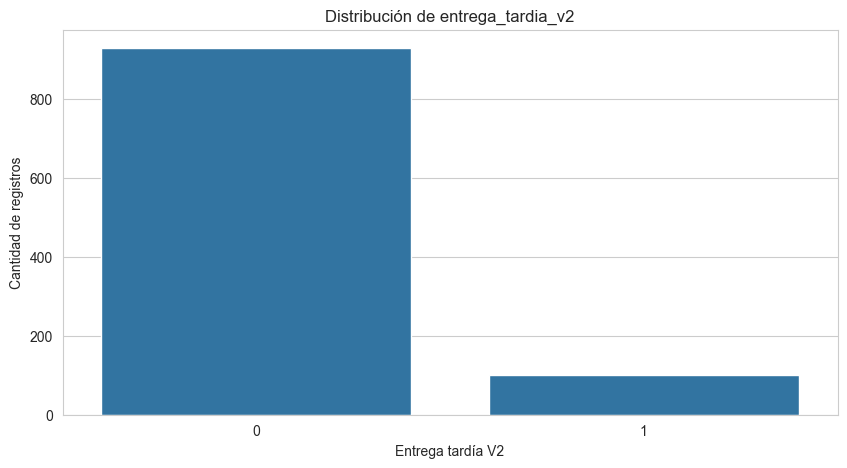

In [5]:
# Visualización de la distribución de la variable objetivo.
sns.countplot(data=df, x="entrega_tardia_v2")

plt.title("Distribución de entrega_tardia_v2")
plt.xlabel("Entrega tardía V2")
plt.ylabel("Cantidad de registros")

plt.show()


## Interpretación

La variable `entrega_tardia_v2` sigue estando desbalanceada, porque la clase `0` es mayoritaria.  
Sin embargo, el desbalance es mucho menos extremo que en la variable original.

Esto permite entrenar modelos de clasificación, pero obliga a evaluar cuidadosamente métricas como:

- Recall
- Precision
- F1-score
- Balanced accuracy

En este contexto, el accuracy por sí solo puede ser engañoso.


# 4. Selección de variables predictoras

Se utilizan variables logísticas relacionadas con distancia, carga, capacidad, incidencias, velocidad y características del envío.

Se excluyen variables que podrían causar fuga de información, especialmente:

- `dias_entrega`, porque se usó para construir la variable objetivo;
- `fecha_entrega`, porque solo se conoce al finalizar el envío;
- `entrega_tardia`, porque corresponde a la versión anterior del target;
- `entrega_tardia_v2`, porque es la variable que se quiere predecir.


In [6]:
# Variables seleccionadas para el modelo.
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

# Variable objetivo.
objetivo = "entrega_tardia_v2"

# Construcción de X e y.
X = df[variables_modelo]
y = df[objetivo]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (1030, 14)
Dimensiones de y: (1030,)


# 5. Revisión de valores nulos

Antes de evaluar modelos, se revisan los valores nulos en las variables seleccionadas.

Estos nulos serán tratados dentro del pipeline de Scikit-learn, no directamente sobre el DataFrame original.


In [7]:
# Revisión de nulos en variables predictoras.
nulos = X.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]



capacidad_kg           31
capacidad_m3           31
estado_vehiculo        31
tiempo_estimado_hrs    28
tipo_via               28
distancia_km           28
dtype: int64

# 6. Preprocesamiento

El preprocesamiento se realiza con `Pipeline` y `ColumnTransformer`.

Esto permite aplicar tratamientos distintos según el tipo de variable:

## Variables numéricas

- imputación con mediana;
- escalado con StandardScaler.

## Variables categóricas

- imputación con valor más frecuente;
- transformación con OneHotEncoder.

Este enfoque es reproducible y evita modificar manualmente los datos.


In [8]:
# Identificamos variables numéricas.
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()

# Identificamos variables categóricas.
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)


Variables numéricas:
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'cantidad_incidencias', 'tiene_incidencia', 'uso_capacidad_kg', 'uso_capacidad_m3', 'velocidad_promedio_km_h']

Variables categóricas:
['tipo_via', 'tipo_carga', 'estado_vehiculo']


In [9]:
# Pipeline para variables numéricas.
transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas.
transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador general.
preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 7. División en entrenamiento y prueba

Se usa una división 80/20:

- 80% de los datos para entrenamiento;
- 20% para prueba.

Se utiliza `stratify=y` para mantener proporciones similares de clases en ambos conjuntos.


In [10]:
# División de datos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)


X_train: (824, 14)
X_test: (206, 14)

Distribución en entrenamiento:
entrega_tardia_v2
0    90.169903
1     9.830097
Name: proportion, dtype: float64

Distribución en prueba:
entrega_tardia_v2
0    90.291262
1     9.708738
Name: proportion, dtype: float64


# 8. Modelos a evaluar

Se evaluarán tres modelos base:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Se utiliza `class_weight="balanced"` para reducir el impacto del desbalance de clases.


In [11]:
# Definimos los modelos dentro de pipelines completos.
# Cada pipeline incluye preprocesamiento + modelo.

modelos = {
    "Logistic Regression": Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", RandomForestClassifier(
            random_state=42,
            n_estimators=100,
            class_weight="balanced"
        ))
    ])
}


# 9. Función de evaluación

Se crea una función para evaluar todos los modelos de forma consistente.

La función calcula:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

En este problema, el F1-score y el recall son especialmente importantes porque la clase tardía es minoritaria.


In [12]:
def evaluar_modelo(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    """Entrena y evalúa un modelo de clasificación.

    Parameters
    ----------
    nombre_modelo : str
        Nombre del modelo evaluado.
    modelo : Pipeline
        Pipeline de Scikit-learn con preprocesamiento y modelo.
    X_train, X_test : DataFrame
        Variables predictoras de entrenamiento y prueba.
    y_train, y_test : Series
        Variable objetivo de entrenamiento y prueba.

    Returns
    -------
    dict
        Métricas principales y predicciones del modelo.
    """

    # Entrenar el modelo con los datos de entrenamiento.
    modelo.fit(X_train, y_train)

    # Generar predicciones sobre el conjunto de prueba.
    y_pred = modelo.predict(X_test)

    # Calcular métricas principales.
    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Guardar la matriz de confusión.
    matriz = confusion_matrix(y_test, y_pred)

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Visualización de matriz de confusión.
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "matriz_confusion": matriz,
        "y_pred": y_pred
    }


# 10. Evaluación de modelos

Se entrenan y evalúan los tres modelos definidos.


===== Logistic Regression =====
Accuracy          : 0.6165
Balanced Accuracy : 0.5199
Precision         : 0.1067
Recall            : 0.4000
F1-score          : 0.1684

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       186
           1       0.11      0.40      0.17        20

    accuracy                           0.62       206
   macro avg       0.51      0.52      0.46       206
weighted avg       0.83      0.62      0.69       206



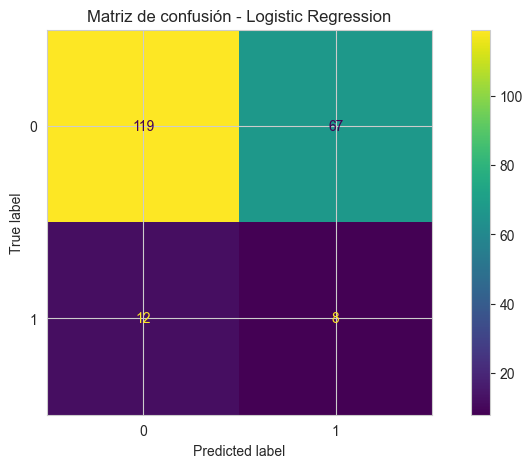

===== Decision Tree =====
Accuracy          : 0.7621
Balanced Accuracy : 0.5559
Precision         : 0.1463
Recall            : 0.3000
F1-score          : 0.1967

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       186
           1       0.15      0.30      0.20        20

    accuracy                           0.76       206
   macro avg       0.53      0.56      0.53       206
weighted avg       0.84      0.76      0.80       206



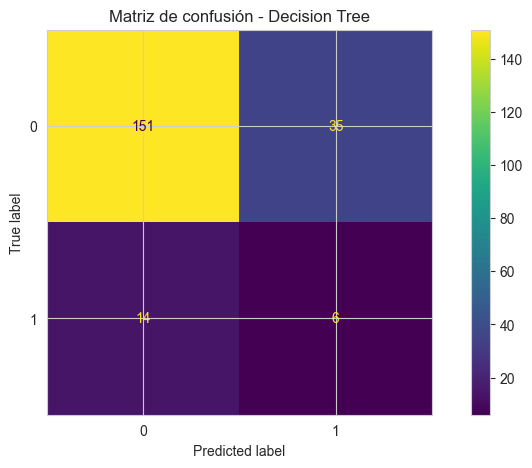

===== Random Forest =====
Accuracy          : 0.9029
Balanced Accuracy : 0.5000
Precision         : 0.0000
Recall            : 0.0000
F1-score          : 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       186
           1       0.00      0.00      0.00        20

    accuracy                           0.90       206
   macro avg       0.45      0.50      0.47       206
weighted avg       0.82      0.90      0.86       206



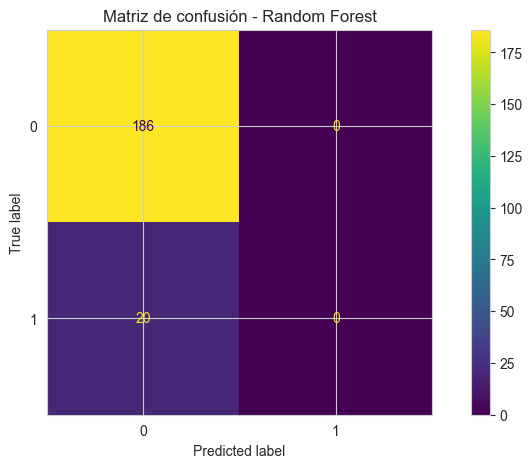

In [13]:
# Lista para almacenar resultados.
resultados_modelos = []

# Entrenamos y evaluamos cada modelo.
for nombre, modelo in modelos.items():
    resultado = evaluar_modelo(
        nombre,
        modelo,
        X_train,
        X_test,
        y_train,
        y_test
    )

    resultados_modelos.append(resultado)


# 11. Tabla comparativa de métricas

Se consolidan las métricas principales en una tabla para facilitar la comparación.


In [14]:
# Convertimos los resultados a DataFrame, excluyendo objetos no tabulares.
tabla_resultados = pd.DataFrame([
    {
        "modelo": r["modelo"],
        "accuracy": r["accuracy"],
        "balanced_accuracy": r["balanced_accuracy"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1_score": r["f1_score"]
    }
    for r in resultados_modelos
])

tabla_resultados.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
1,Decision Tree,0.762136,0.555914,0.146341,0.3,0.196721
0,Logistic Regression,0.616505,0.519892,0.106667,0.4,0.168421
2,Random Forest,0.902913,0.500000,0.000000,0.0,0.000000


## Interpretación de métricas

En este problema no basta con mirar `accuracy`, porque la clase mayoritaria es la clase `0`.

Por eso se priorizan:

- `recall`, para saber cuántas entregas tardías logra detectar el modelo;
- `precision`, para saber qué tan confiables son las predicciones de tardanza;
- `f1_score`, porque combina precision y recall;
- `balanced_accuracy`, porque considera el rendimiento en ambas clases.


# 12. Visualización comparativa de métricas

Se grafican las métricas principales para observar diferencias entre modelos.


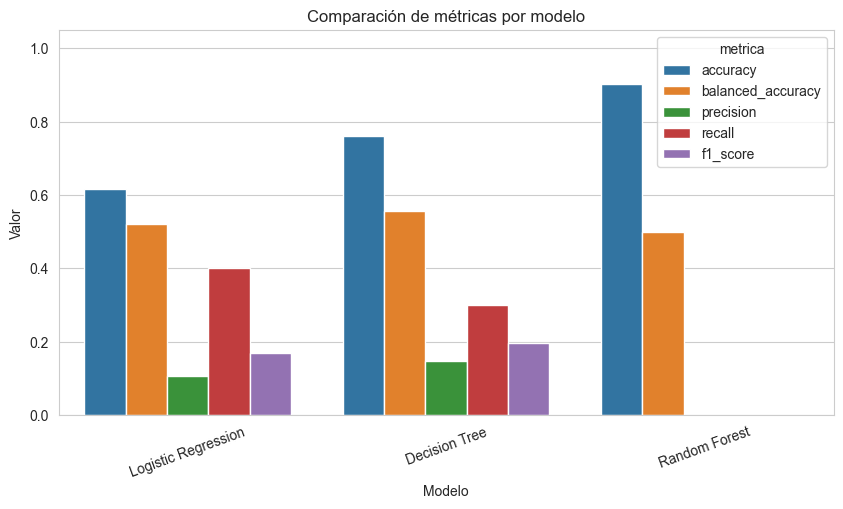

In [15]:
# Transformamos la tabla a formato largo para graficar.
tabla_melt = tabla_resultados.melt(
    id_vars="modelo",
    value_vars=[
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score"
    ],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=tabla_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()


# 13. Análisis de matrices de confusión

La matriz de confusión permite analizar errores concretos del modelo.

En este problema:

- Verdadero negativo: entrega normal predicha como normal.
- Falso positivo: entrega normal predicha como tardía.
- Falso negativo: entrega tardía predicha como normal.
- Verdadero positivo: entrega tardía predicha como tardía.

Los falsos negativos son importantes porque representan entregas tardías que el modelo no detectó.


In [16]:
# Mostramos matrices como tablas para interpretación numérica.
for r in resultados_modelos:
    matriz = r["matriz_confusion"]

    matriz_df = pd.DataFrame(
        matriz,
        index=["Real 0", "Real 1"],
        columns=["Predicho 0", "Predicho 1"]
    )

    print(f"\nMatriz de confusión - {r['modelo']}")
    display(matriz_df)



Matriz de confusión - Logistic Regression


,Predicho 0,Predicho 1
Real 0,119,67
Real 1,12,8



Matriz de confusión - Decision Tree


,Predicho 0,Predicho 1
Real 0,151,35
Real 1,14,6



Matriz de confusión - Random Forest


,Predicho 0,Predicho 1
Real 0,186,0
Real 1,20,0


# 14. Selección del mejor modelo base

Para seleccionar el mejor modelo base se considera principalmente el F1-score y el recall de la clase positiva.

Esto se debe a que el objetivo principal es detectar entregas tardías, no solo acertar la mayoría de registros normales.


In [17]:
# Ordenamos por F1-score.
mejor_por_f1 = tabla_resultados.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_por_f1



modelo               Decision Tree
accuracy                  0.762136
balanced_accuracy         0.555914
precision                 0.146341
recall                         0.3
f1_score                  0.196721
Name: 1, dtype: object

## Interpretación

El modelo con mejor F1-score es el mejor candidato inicial para la siguiente etapa.  
Sin embargo, si otro modelo tiene mejor recall, también puede ser interesante dependiendo del objetivo de negocio.

Por ejemplo:

- Si la empresa quiere detectar la mayor cantidad posible de entregas tardías, se prioriza recall.
- Si la empresa quiere evitar falsas alarmas, se prioriza precision.
- Si se quiere equilibrio entre ambos, se prioriza F1-score.


# 15. Conclusiones de evaluación

A partir de la evaluación comparativa se observa que:

- La nueva variable `entrega_tardia_v2` permite evaluar modelos de manera más realista que la variable original.
- El problema sigue presentando desbalance de clases, por lo que accuracy no debe ser la métrica principal.
- Random Forest puede mostrar alto accuracy, pero si no detecta la clase tardía, no es útil para este objetivo.
- Decision Tree y Logistic Regression pueden ser mejores candidatos si logran detectar más casos tardíos.
- El F1-score y el recall son métricas clave para decidir qué modelo optimizar.

La siguiente etapa será aplicar optimización de hiperparámetros, utilizando técnicas como GridSearchCV, RandomizedSearchCV u Optuna.


# 16. Recomendación para la siguiente etapa

Para el notebook `04_hyperparameter_optimization.ipynb`, se recomienda optimizar primero el modelo que obtenga mejor F1-score.

También se recomienda probar:

- diferentes profundidades para Decision Tree;
- distintos pesos de clase;
- Random Forest con hiperparámetros ajustados;
- Logistic Regression con variaciones en `C`;
- Optuna como alternativa avanzada para búsqueda automática de hiperparámetros.

Esto permitirá comprobar si el rendimiento sobre la clase tardía puede mejorar.
